In [1]:
from src.structure_index import compute_structure_index, draw_graph

In [ ]:
from src.constants import PROCESSED_DATA_PATH, INTERIM_DATA_PATH
from src.utils import hd_tuning, circ_colors, plot_tuning_grid, plot_intervals, find_outliers

import numpy as np
import pandas as pd
import pynapple as nap
import seaborn as sns
import matplotlib.colors as mcolors
import umap
import umap.plot
import xarray as xr

from matplotlib import pyplot as plt
from scipy.io import loadmat
from scipy.signal.windows import gaussian

import pynaviz as viz
from pynaviz import scope

# === CONFIG ===
unit_id = "116b"
WAKE_BIN = 0.1
NREM_BIN = 0.05
SMOOTH_STD = 0.2
SMOOTH_WIN = 2
UMAP_NEIGHBORS = 200
UMAP_MIN_DIST = 0.2

custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", palette="colorblind", font_scale=1.5, rc=custom_params)

In [ ]:
sleep_states    = nap.load_file(PROCESSED_DATA_PATH / unit_id / "sleep.npz")
hd_spikes       = nap.load_file(PROCESSED_DATA_PATH / unit_id / "hd_spikes_filtered.npz")
hd_angle        = nap.load_file(PROCESSED_DATA_PATH / unit_id / "angle_openfield.npz")
sessions        = nap.load_file(PROCESSED_DATA_PATH / unit_id / "sessions_labeled.npz")

wake_rate shape: (21095, 81)


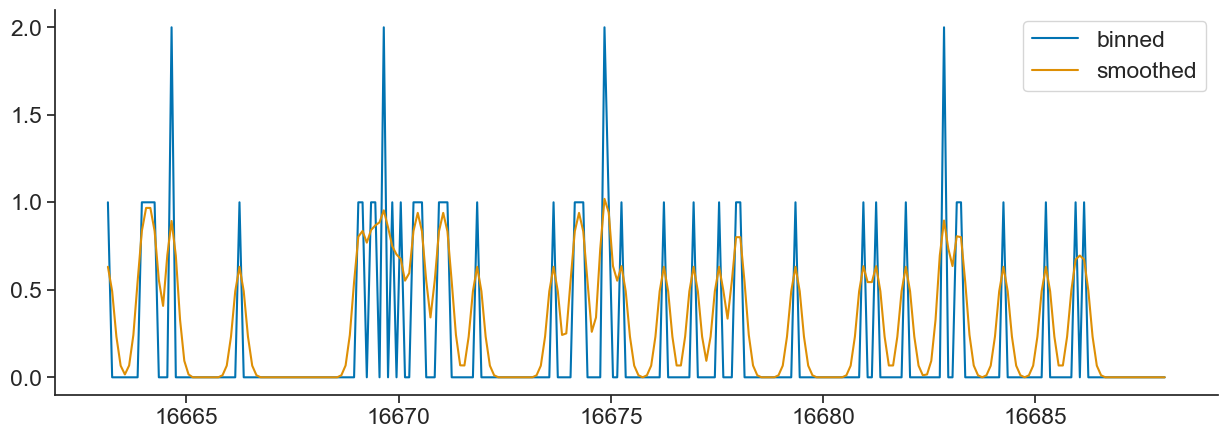

In [22]:
epochs = hd_angle.time_support
WAKE_BIN = 0.1
SMOOTH_STD = 0.2
SMOOTH_WIN = 1

hd_angle = hd_angle.bin_average(bin_size=WAKE_BIN, ep=epochs)
binned = hd_spikes.count(bin_size=WAKE_BIN, ep=epochs)
wake_rate = np.sqrt(binned.smooth(std=SMOOTH_STD, windowsize=SMOOTH_WIN))

print(f"wake_rate shape: {wake_rate.shape}")

# Smoothing effect
t_a, t_b = 0, 250
channel = 7

plt.figure(figsize=(15, 5))
plt.plot(binned[t_a:t_b, channel])
plt.plot(wake_rate[t_a:t_b, channel])
plt.legend(['binned', 'smoothed'])

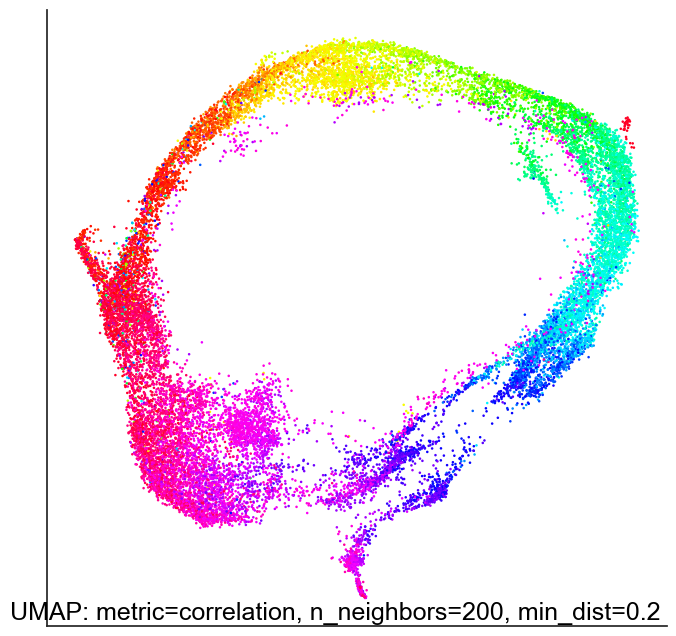

In [6]:
reducer = umap.UMAP(n_neighbors=UMAP_NEIGHBORS, min_dist=UMAP_MIN_DIST, n_components=2, metric='correlation')
reducer.fit(wake_rate)
wake_embds = reducer.embedding_
_ = umap.plot.points(reducer, values=hd_angle.values, cmap='hsv')

In [17]:
from src.structure_index import compute_structure_index, draw_graph

# Compute Structure Index for wake manifold
SI, bin_label, overlap_mat, shuf_SI = compute_structure_index(
    data=wake_embds,
    label=hd_angle.values.reshape(-1, 1),
    n_bins=60,
    n_neighbors=15,
    num_shuffles=100,
    verbose=True
)

print(f"Structure Index: {SI:.3f}")
print(f"Shuffle 99th percentile: {np.percentile(shuf_SI, 99):.3f}")

Computing bin-groups..: Done


Computing overlap:   0%|          | 0/1770 [00:00<?, ?it/s]

Computing structure index..: 0.81


Computing shuffling:   0%|          | 0/100 [00:00<?, ?it/s]

Shuffling 99th percentile: 0.00
Structure Index: 0.806
Shuffle 99th percentile: 0.001


In [23]:
tcs = nap.compute_tuning_curves(hd_spikes, np.deg2rad(hd_angle), 60, epochs=epochs, range=(0, 2*np.pi))
tcs

<xarray.DataArray (unit: 81, 0: 60)> Size: 39kB
array([[0.20408163, 0.14084507, 0.09345794, ..., 0.06587615, 0.04807692,
        0.10615711],
       [2.9478458 , 3.66197183, 5.29595016, ..., 4.49275362, 3.85817308,
        2.56900212],
       [0.58956916, 0.58350101, 0.74766355, ..., 0.6455863 , 0.55288462,
        0.59447983],
       ...,
       [0.40816327, 0.58350101, 0.46728972, ..., 0.7773386 , 0.64903846,
        0.44585987],
       [0.04535147, 0.14084507, 0.0623053 , ..., 0.23715415, 0.13221154,
        0.16985138],
       [0.27210884, 0.26156942, 0.28037383, ..., 0.36890646, 0.34855769,
        0.21231423]], shape=(81, 60))
Coordinates:
  * unit     (unit) int64 648B 0 1 2 3 4 5 6 7 8 ... 72 73 74 75 76 77 78 79 80
  * 0        (0) float64 480B 0.05236 0.1571 0.2618 0.3665 ... 6.021 6.126 6.231
Attributes:
    occupancy:  [ 441.  497.  321.  194.  160.  125.  153.  187.  363.  651. ...
    bin_edges:  [array([0.        , 0.10471976, 0.20943951, 0.31415927, 0.418...
    fs:         10.00000000000001
    rates:      [0.59159817 2.45882989 0.35789793 4.39432293 0.80870711 4.491...

Text(0.5, 1.0, 'HD Structure (SI=0.82)')

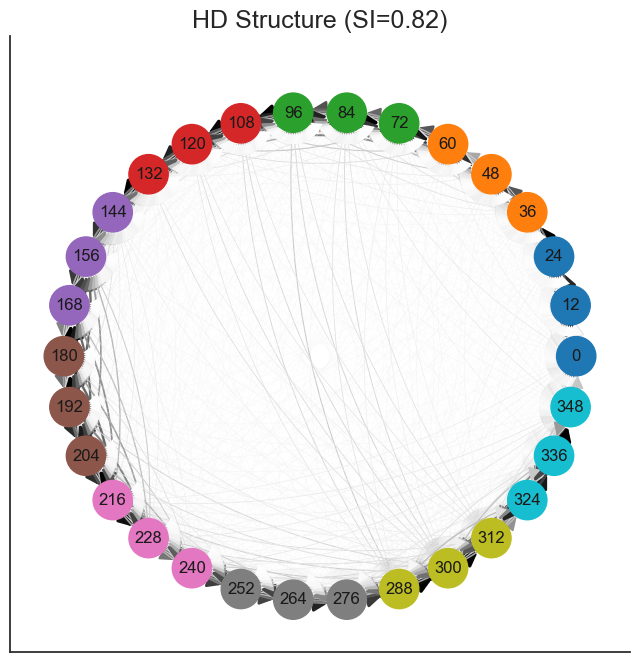

In [ ]:
# Visualize the overlap graph
fig, ax = plt.subplots(figsize=(8, 8))
draw_graph(overlap_mat, ax, node_names=np.arange(0, 360, 12))  # Label nodes by angle
plt.title(f"HD Structure (SI={SI:.2f})")

smooth_rate shape: (200000, 81)


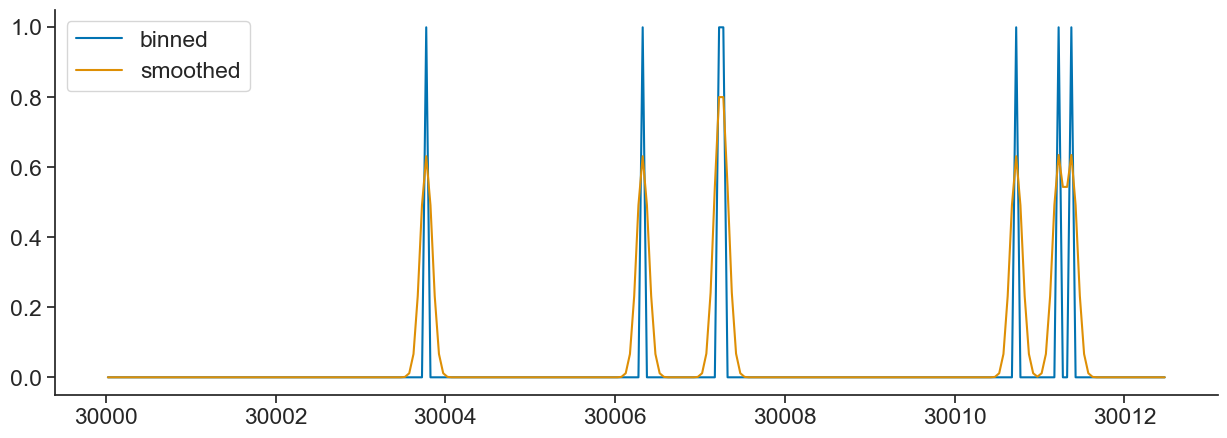

In [24]:
epochs = nap.IntervalSet(start=[30000], end=[40000])

bin_size = NREM_BIN
std = 0.05
win = 0.5

binned = hd_spikes.count(bin_size=bin_size, ep=epochs)
smooth_rate = np.sqrt(binned.smooth(std=std, windowsize=win))
print(f"smooth_rate shape: {smooth_rate.shape}")

# Smoothing effect
t_a, t_b = 0, 250
channel = 7

plt.figure(figsize=(15, 5))
plt.plot(binned[t_a:t_b, channel])
plt.plot(smooth_rate[t_a:t_b, channel])
plt.legend(['binned', 'smoothed'])

In [26]:
# Decode during sleep epochs
decoded_hd, proba_feature = nap.decode_bayes(
    tuning_curves=tcs,  # from wake
    data=hd_spikes,                  # same neurons
    epochs=epochs,          # IntervalSet for NREM/REM
    bin_size=0.05,                # time bin in seconds
    sliding_window_size=4,        # optional smoothing (# of bins)
)

decoded_hd

Time (s)
----------  -------
30000.025   3.92699
30000.075   3.92699
30000.125   3.92699
30000.175   4.03171
30000.225   4.24115
30000.275   4.34587
30000.325   4.34587
...
39999.675   5.28835
39999.725   5.28835
39999.775   0.15708
39999.825   5.28835
39999.875   3.19395
39999.925   2.98451
39999.975   3.08923
dtype: float64, shape: (200000,)

In [1]:
decoded_hd

NameError: name 'decoded_hd' is not defined

In [38]:
decoded_hd.save(PROCESSED_DATA_PATH / unit_id / "decoded_hd_nrem.npz")

In [13]:
sleep_embds = reducer.transform(smooth_rate)

In [35]:
# Compute Structure Index for wake manifold
SI, bin_label, overlap_mat, shuf_SI = compute_structure_index(
    data=sleep_embds,
    label=decoded_hd.values.reshape(-1, 1),
    n_bins=30,
    n_neighbors=15,
    num_shuffles=20,
    verbose=True
)

print(f"Structure Index: {SI:.3f}")
print(f"Shuffle 99th percentile: {np.percentile(shuf_SI, 99):.3f}")

Computing bin-groups..: Done


Computing overlap:   0%|          | 0/406 [00:00<?, ?it/s]

Computing structure index..: 0.73


Computing shuffling:   0%|          | 0/20 [00:00<?, ?it/s]

Shuffling 99th percentile: 0.00
Structure Index: 0.733
Shuffle 99th percentile: 0.001
